# فاز اول — آماده‌سازی داده و ارزیابی گرایش به خوشه‌بندی

**داده:** Stack Overflow Developer Survey 2024  
**سؤال:** کشف پروفایل‌های طبیعی توسعه‌دهندگان براساس پشته فناوری، تجربه و بستر کاری.

این نوت‌بوک خروجی‌های pipeline بازتولیدپذیر فاز اول را مستقیما از artifactهای ثبت‌شده مرور می‌کند.

In [1]:
from pathlib import Path
import json, sys
import pandas as pd
from IPython.display import display, Image

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
print('Python:', sys.executable)
print('Project root:', ROOT)

Python: C:\Users\ali.hasanzade\AppData\Local\Programs\Python\Python313\python.exe
Project root: C:\personal\uni\sem4\Advanced Data mining\Final Project\Me


## ۱. ورود داده و cohort تحلیلی

In [2]:
ingestion = json.loads((ROOT/'artifacts/ingestion_manifest.json').read_text(encoding='utf-8'))
cleaning = json.loads((ROOT/'artifacts/cleaning_summary.json').read_text(encoding='utf-8'))
pd.DataFrame({
  'شاخص': ['ردیف خام','ستون خام','ستون منتخب','ردیف cohort','ردیف حذف‌شده'],
  'مقدار': [ingestion['rows'], ingestion['source_columns'], ingestion['selected_columns'], cleaning['rows_cleaned'], cleaning['rows_removed']]
})

,شاخص,مقدار
0,ردیف خام,65437
1,ستون خام,114
2,ستون منتخب,21
3,ردیف cohort,60023
4,ردیف حذف‌شده,5414


In [3]:
decisions = pd.read_csv(ROOT/'reports/tables/cleaning_decision_log.csv')
decisions[['column','issue','action','affected_rows']].head(12)

,column,issue,action,affected_rows
0,MainBranch,whitespace/type consistency,strip text and map empty strings to missing,0
1,Employment,whitespace/type consistency,strip text and map empty strings to missing,0
2,RemoteWork,whitespace/type consistency,strip text and map empty strings to missing,0
3,Check,whitespace/type consistency,strip text and map empty strings to missing,0
4,EdLevel,whitespace/type consistency,strip text and map empty strings to missing,0
5,YearsCode,whitespace/type consistency,strip text and map empty strings to missing,0
6,YearsCodePro,whitespace/type consistency,strip text and map empty strings to missing,0
7,DevType,whitespace/type consistency,strip text and map empty strings to missing,0
8,OrgSize,whitespace/type consistency,strip text and map empty strings to missing,0
9,Country,whitespace/type consistency,strip text and map empty strings to missing,0


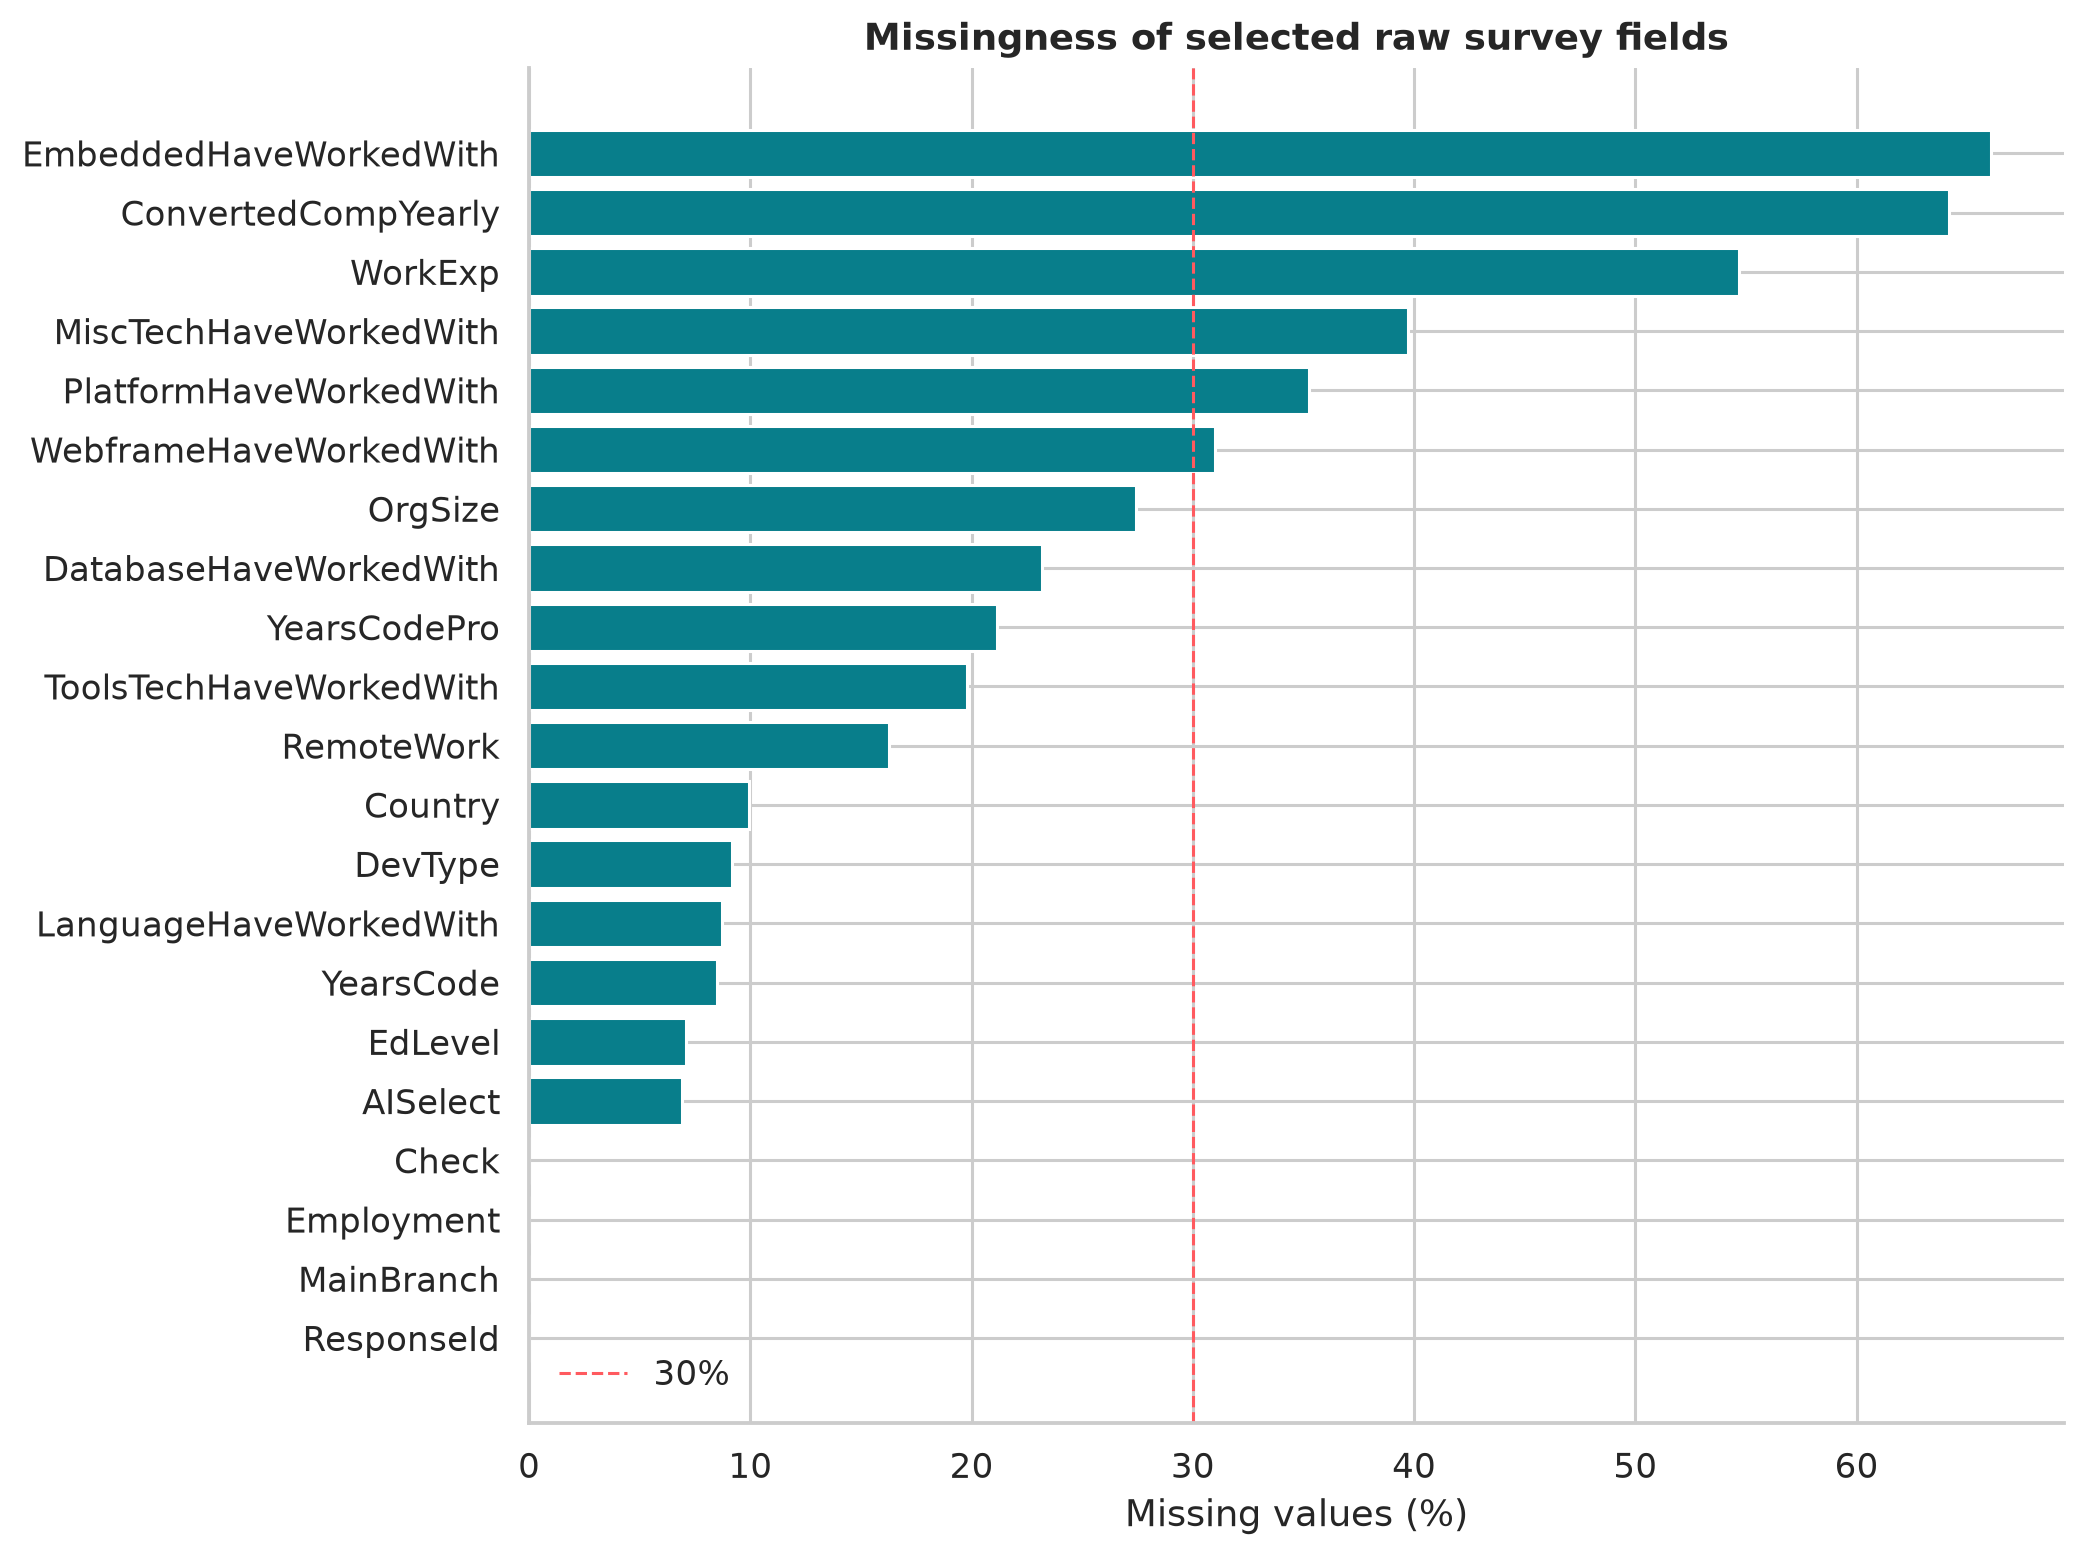

In [4]:
display(Image(filename=ROOT/'reports/figures/phase1_missingness_selected_fields.png', width=850))

۵٬۴۱۴ پاسخ‌دهنده که در هر هفت حوزه فناوری فاقد پاسخ بودند از cohort تحلیلی کنار گذاشته شدند. هیچ ResponseId تکراری و هیچ شکست صریح آزمون توجه مشاهده نشد. مقدارهای تجربه با میانه کشور و fallback سراسری برآورد شدند و indicator گمشدگی حفظ شد.

## ۲. مهندسی ویژگی و scaling

In [5]:
pd.read_csv(ROOT/'reports/tables/feature_inventory.csv')

,block,features
0,numeric,26
1,categorical_one_hot,53
2,employment_multi_hot,9
3,technology_multi_hot,240
4,X_full_total,328
5,X_tech_stack_total,241


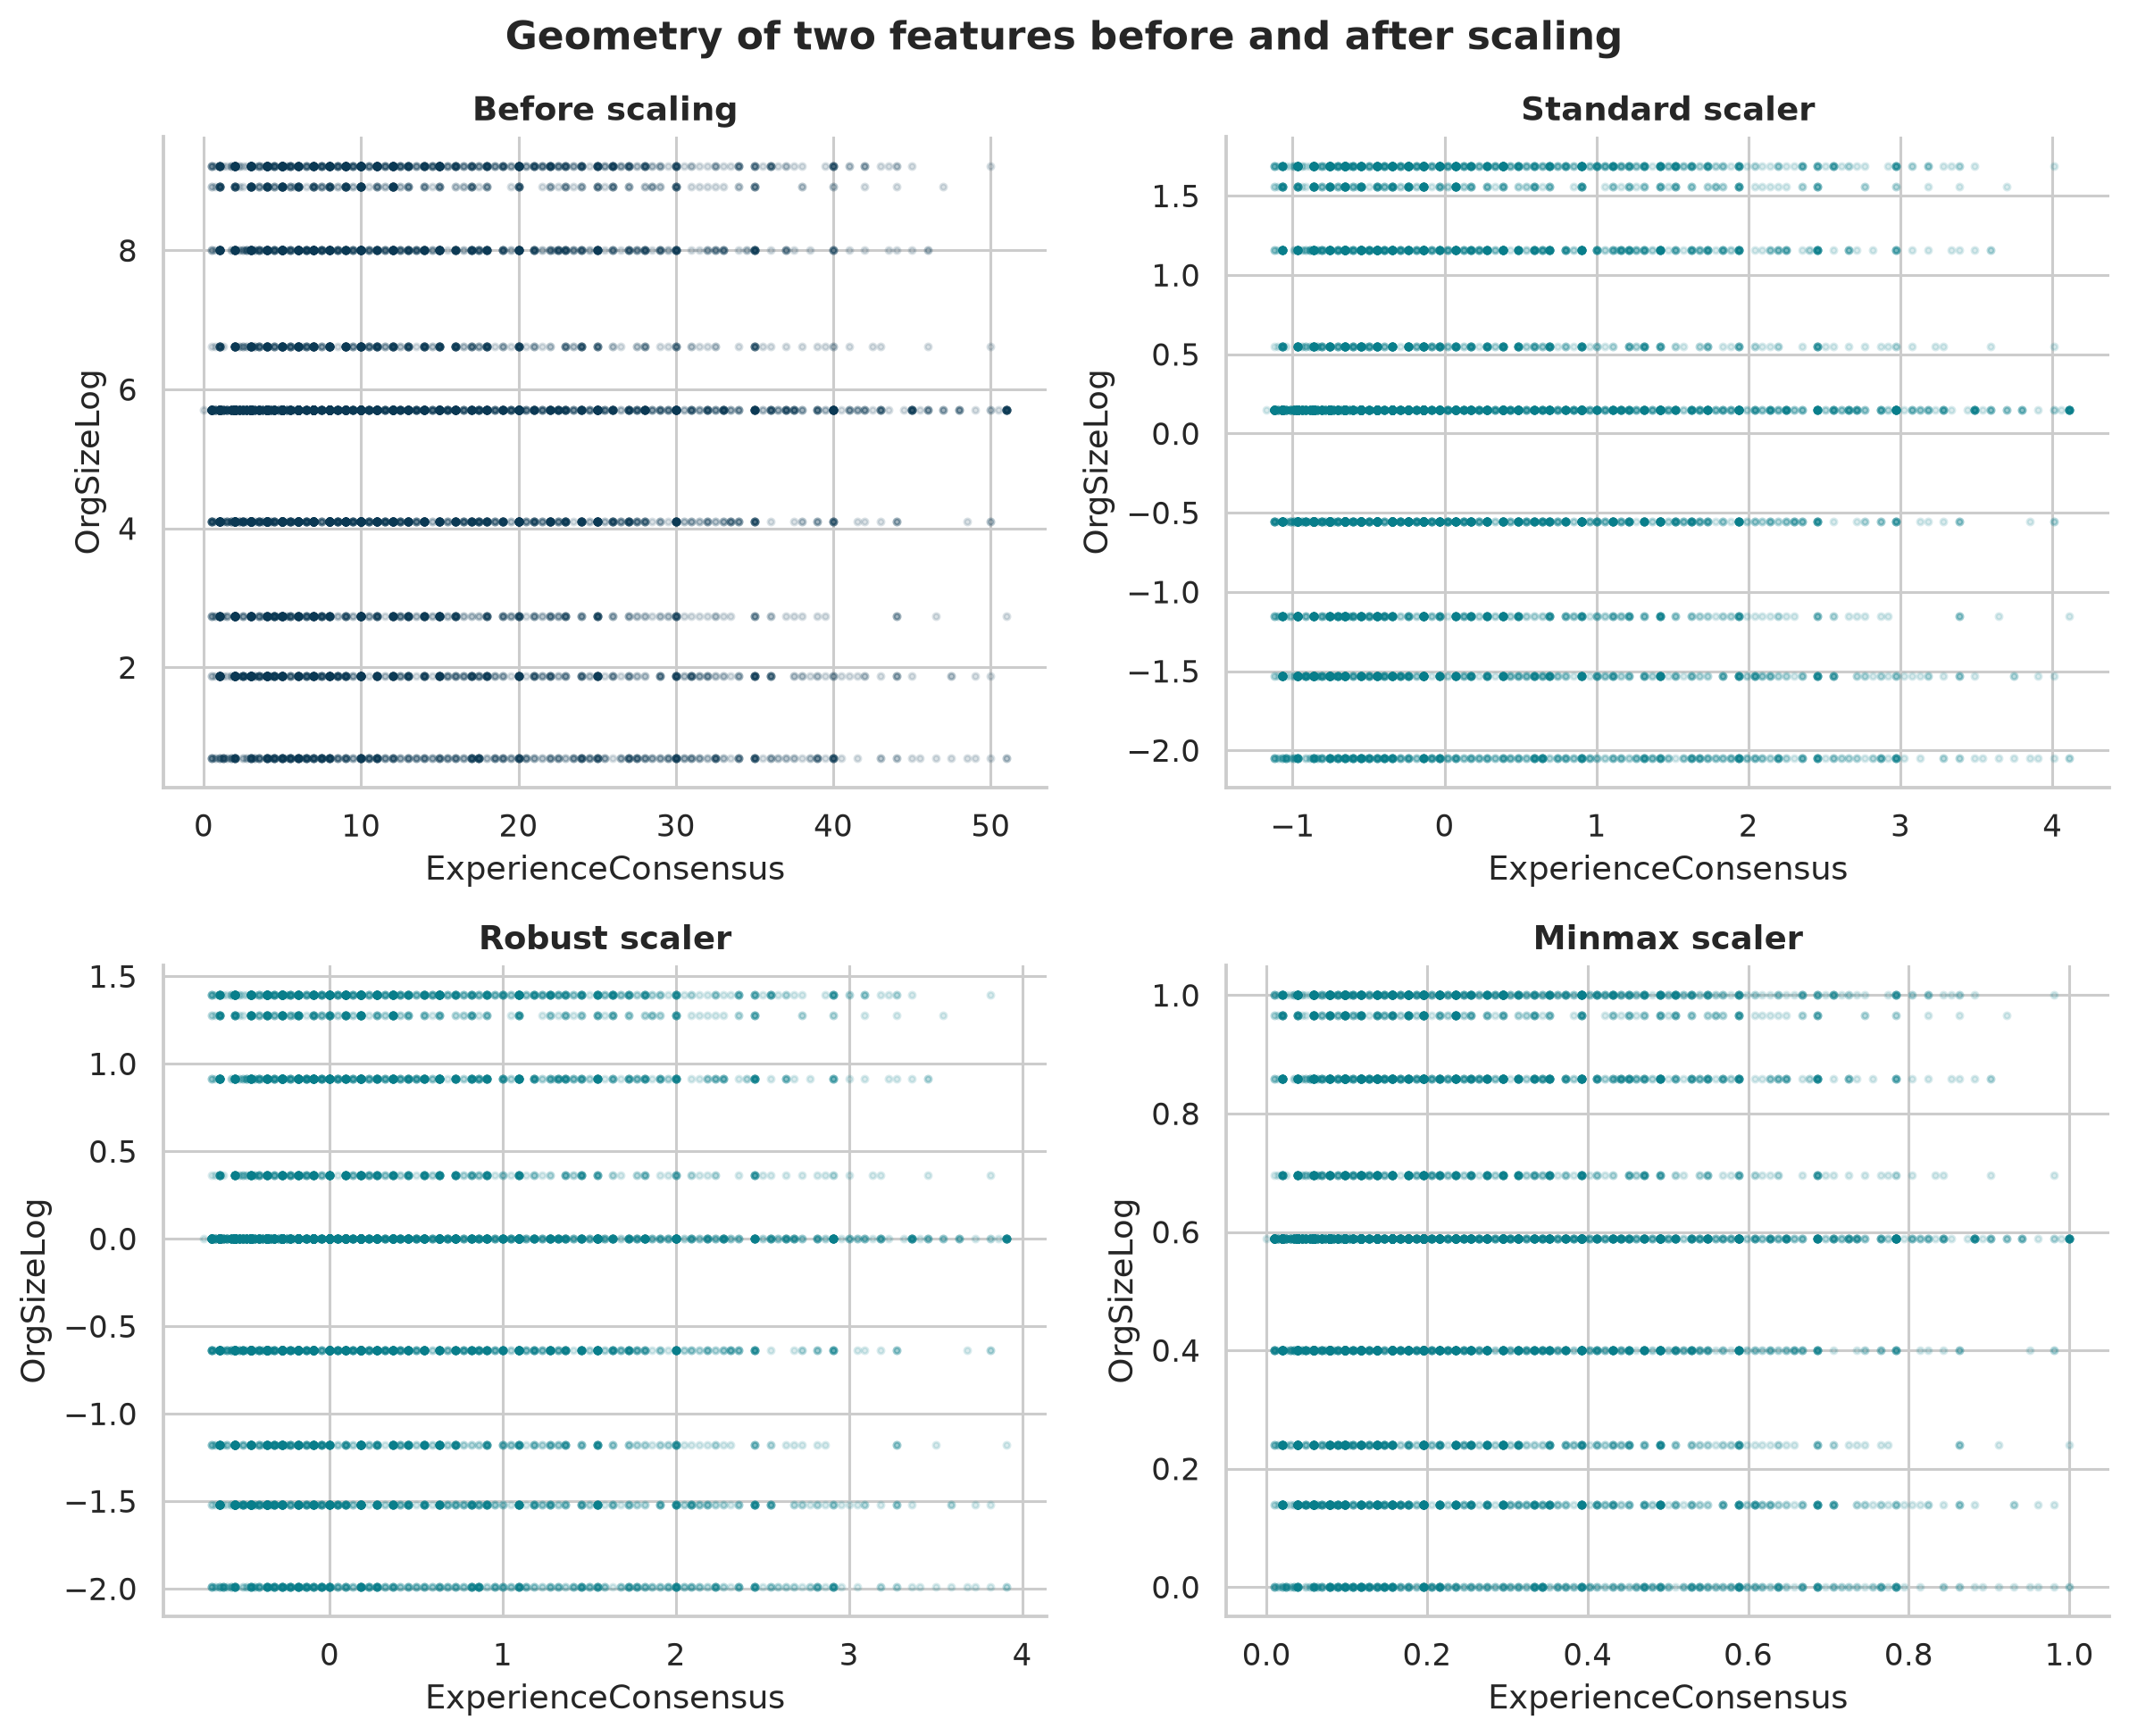

In [6]:
display(Image(filename=ROOT/'reports/figures/phase1_scaler_comparison.png', width=900))

RobustScaler برای بلوک عددی انتخاب شد، زیرا تجربه و اندازه سازمان دنباله‌های سنگین و نقاط دورافتاده واقعی دارند. ویژگی‌های دودویی one-hot/multi-hot بدون center کردن حفظ شدند.

In [7]:
tech = pd.read_csv(ROOT/'reports/tables/technology_prevalence.csv')
tech.sort_values('respondents', ascending=False).head(15)

,domain,technology,respondents,pct_of_cohort
55,Language,JavaScript,37492,62.462723
56,Language,HTML/CSS,31816,53.006348
57,Language,Python,30719,51.178715
58,Language,SQL,30682,51.117072
170,ToolsTech,Docker,29219,48.679673
171,ToolsTech,npm,26866,44.759509
0,Database,PostgreSQL,25536,42.543692
59,Language,TypeScript,23150,38.568549
143,Platform,Amazon Web Services (AWS),22191,36.970828
1,Database,MySQL,21099,35.151525


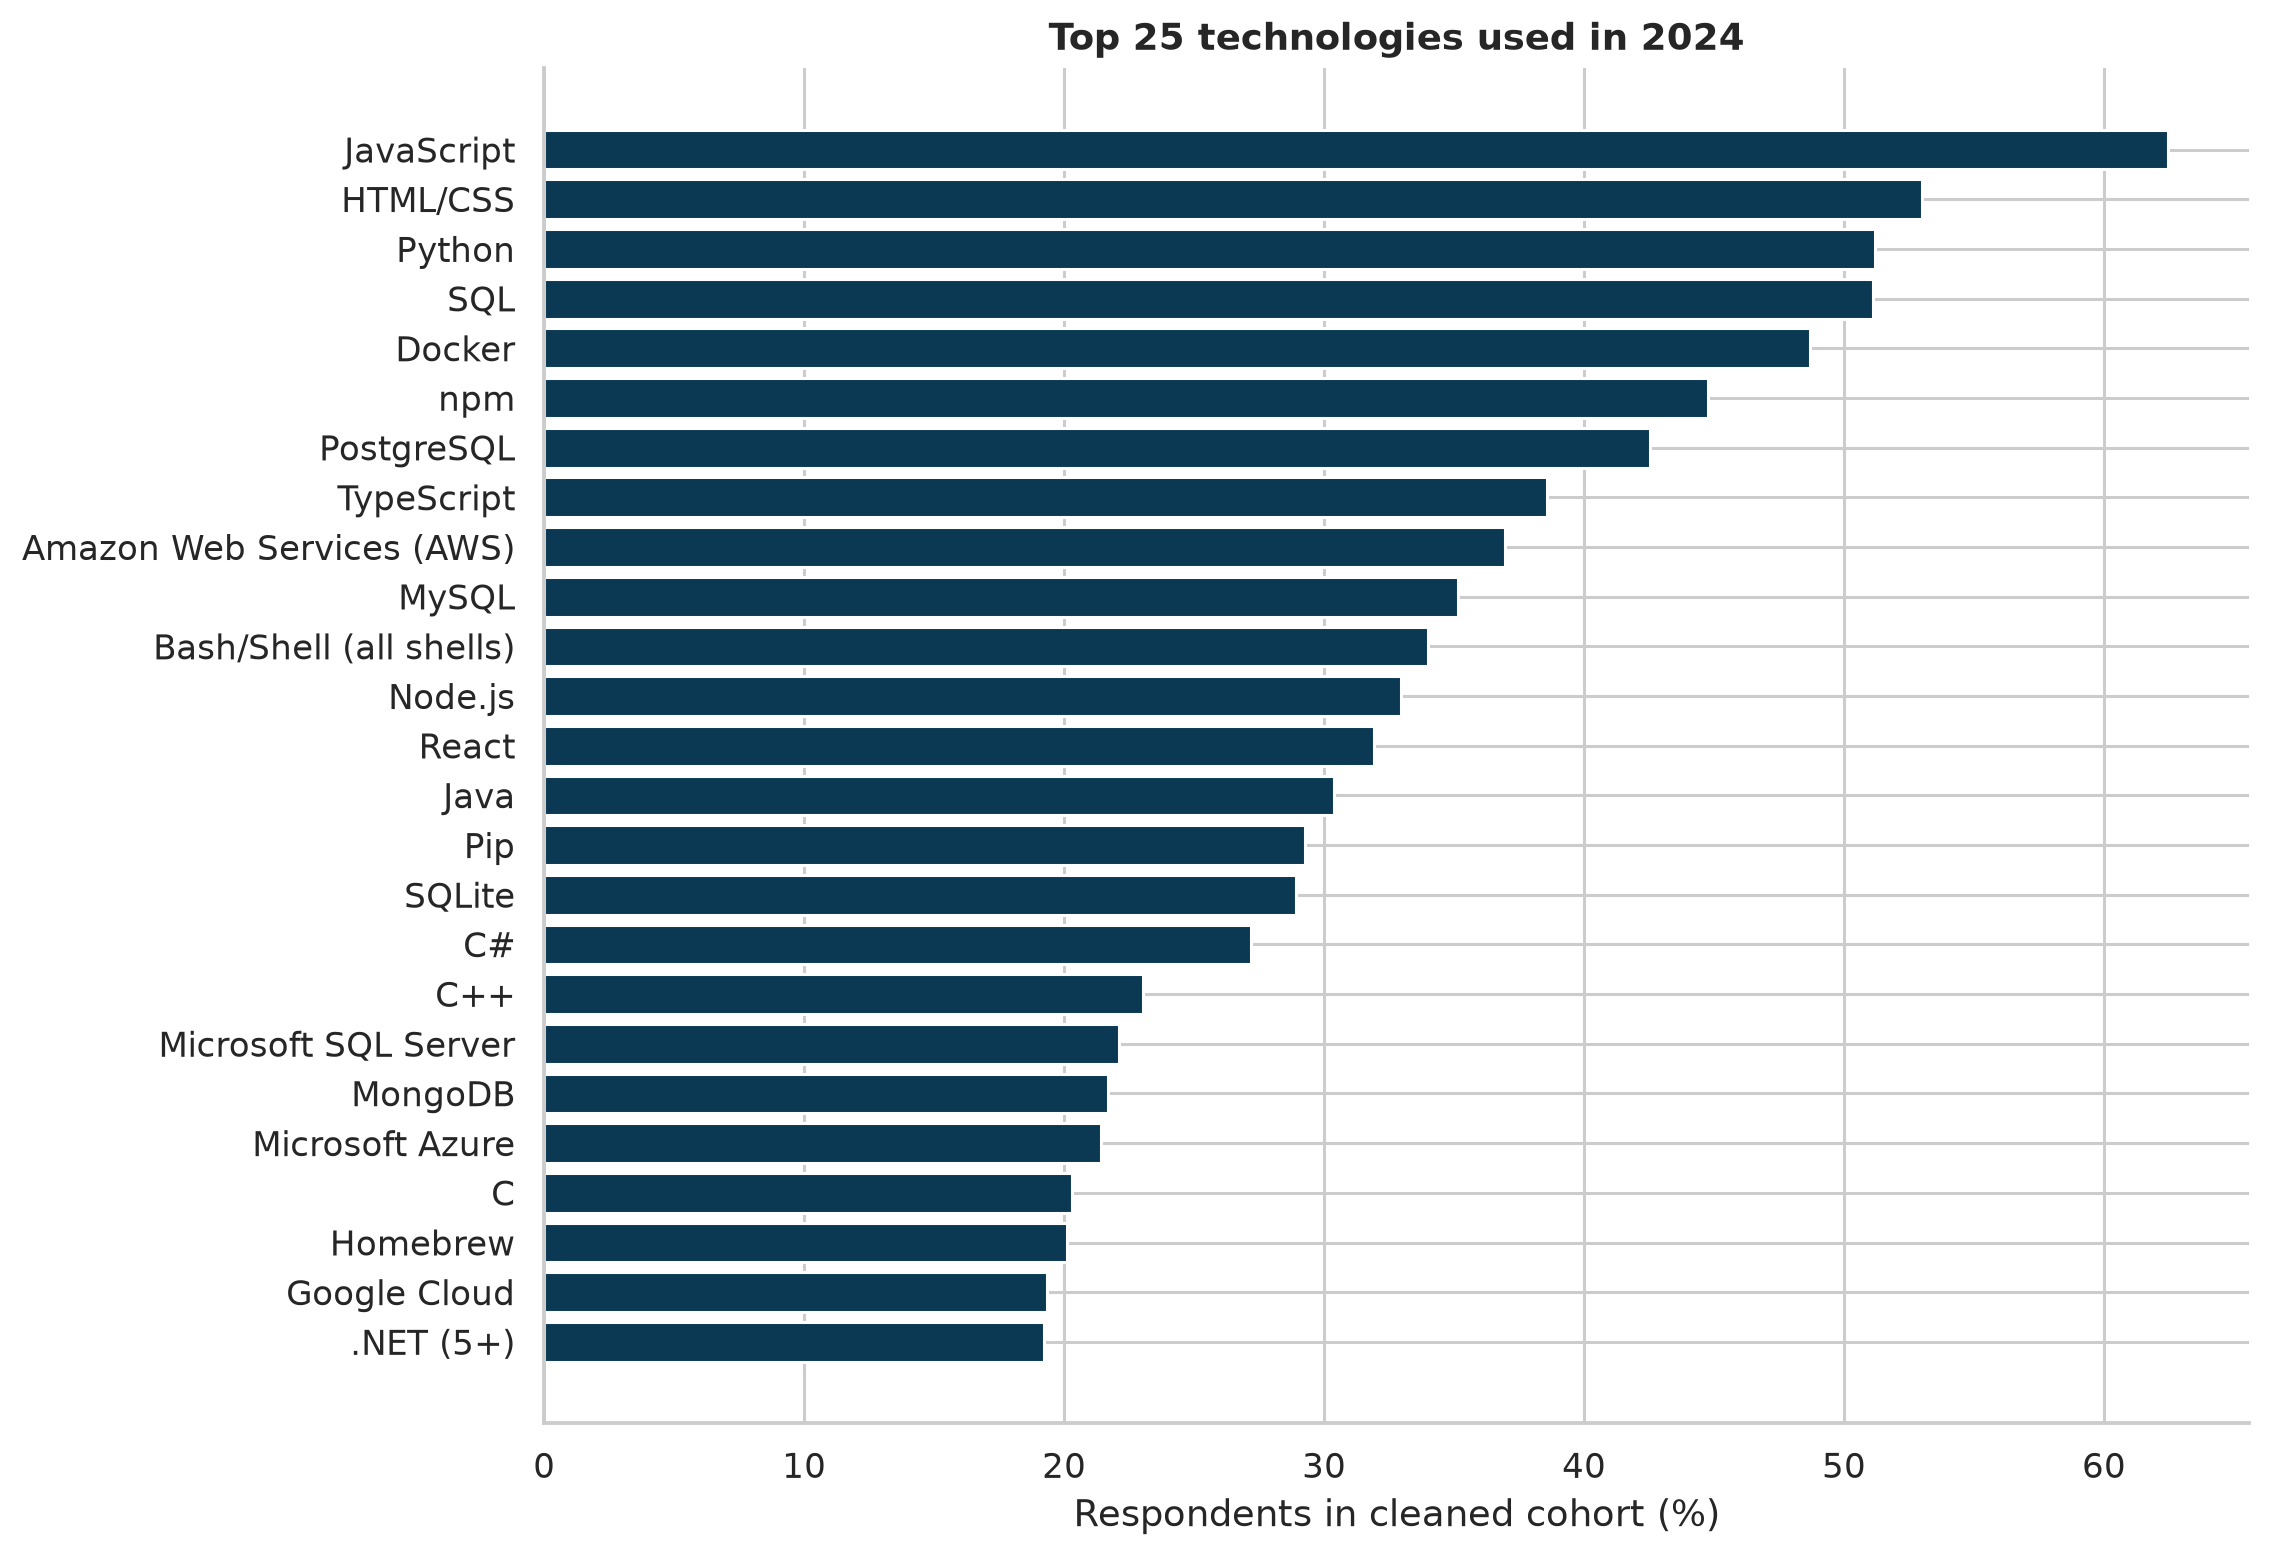

In [8]:
display(Image(filename=ROOT/'reports/figures/phase1_top_technologies.png', width=850))

## ۳. کاهش بعد

In [9]:
reduction = json.loads((ROOT/'artifacts/reduction_manifest.json').read_text(encoding='utf-8'))
pd.Series({
 'ابعاد PCA': str(reduction['pca_shape']),
 'واریانس تجمعی 50 مؤلفه': reduction['pca_cumulative_variance'],
 'ابعاد SVD فناوری': str(reduction['svd_shape']),
 'واریانس تجمعی SVD': reduction['svd_cumulative_variance'],
 'نمونه UMAP': reduction['umap_sample_size'],
 'وضعیت UMAP': reduction['umap_status']
})

ابعاد PCA                 [60023, 50]
واریانس تجمعی 50 مؤلفه       0.777617
ابعاد SVD فناوری          [60023, 50]
واریانس تجمعی SVD            0.693064
نمونه UMAP                      15000
وضعیت UMAP                  completed
dtype: object

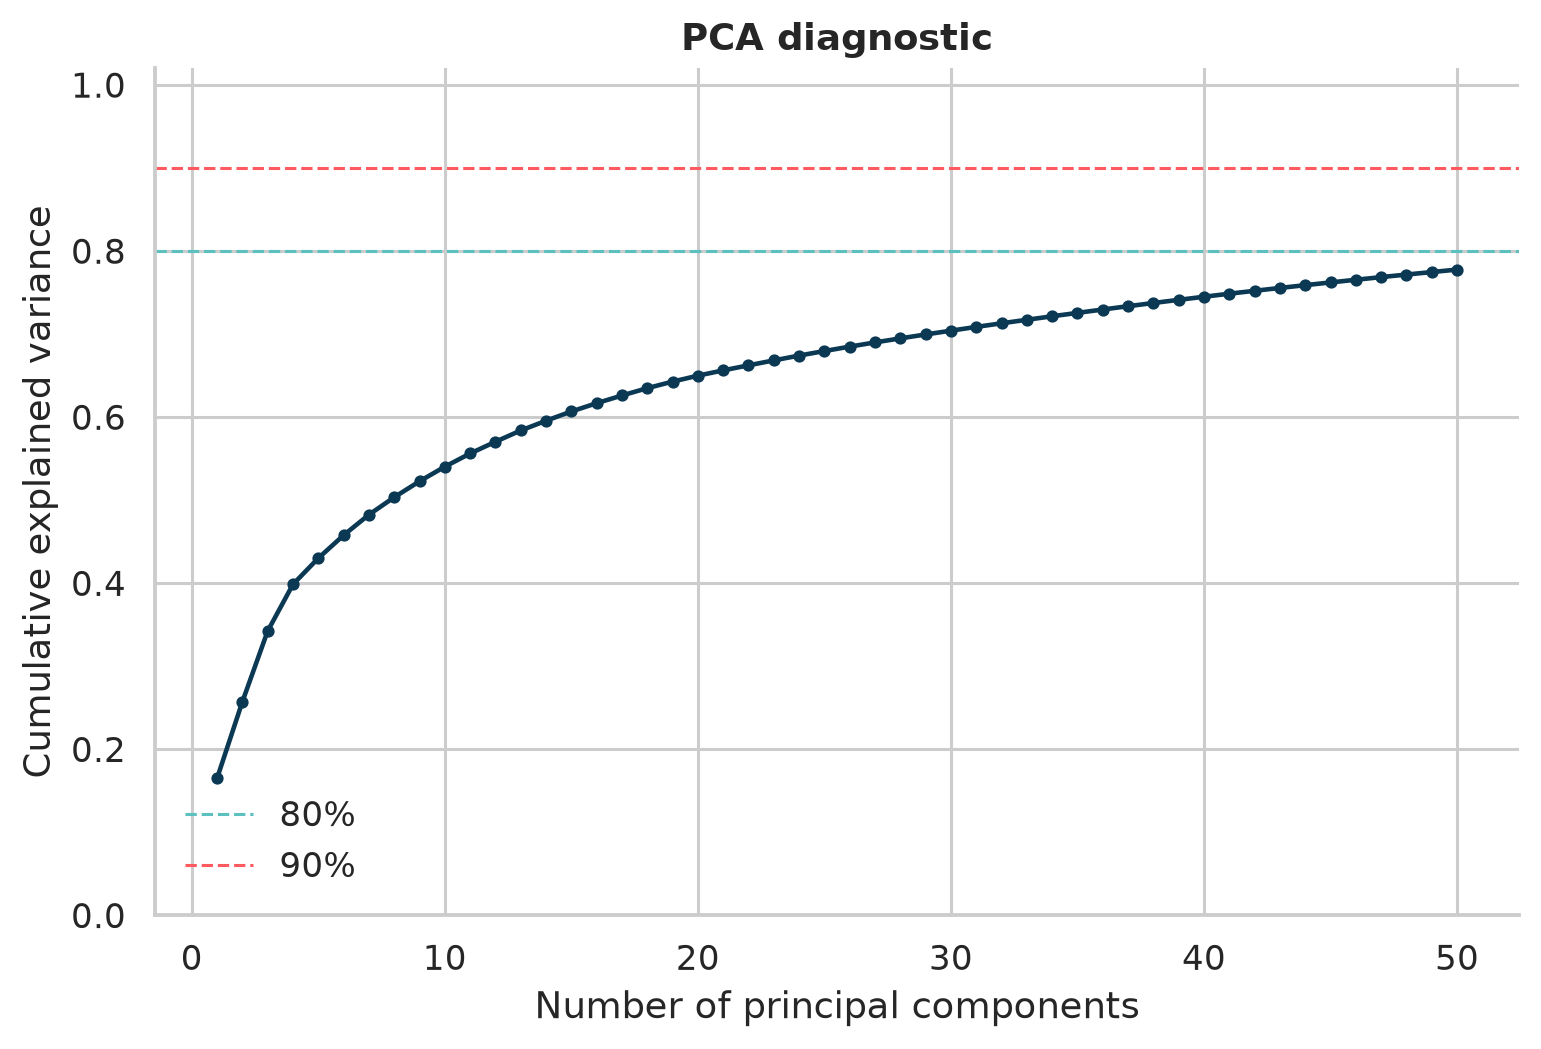

In [10]:
display(Image(filename=ROOT/'reports/figures/phase1_pca_explained_variance.png', width=760))

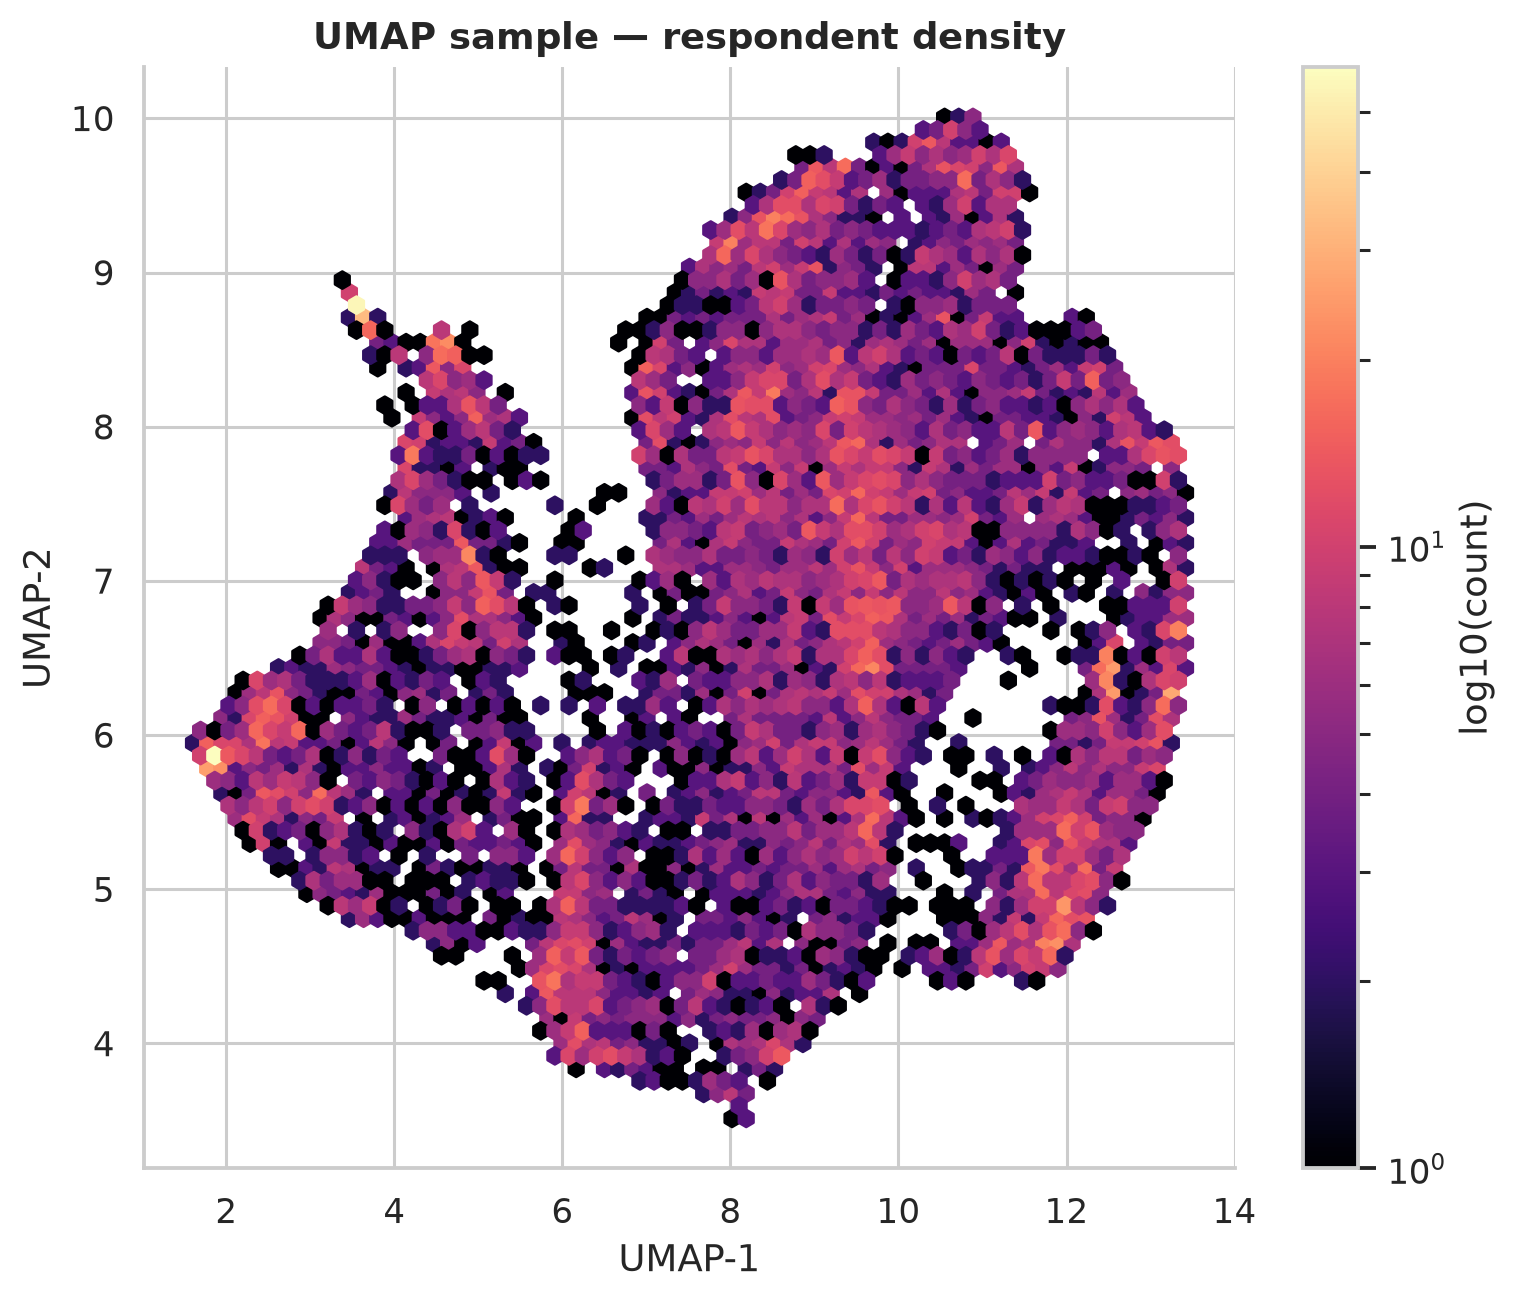

In [11]:
display(Image(filename=ROOT/'reports/figures/phase1_umap_density.png', width=760))

پنجاه مؤلفه PCA برابر ۷۷٫۸٪ واریانس X_full را نگه می‌دارند. این انتخاب مصالحه‌ای میان حفظ اطلاعات و کاهش تمرکز فاصله‌هاست. UMAP وجود نواحی متراکم و ساختار پیوسته/چندلوبی را نشان می‌دهد؛ بنابراین انتظار خوشه‌های کاملا کروی ساده واقع‌بینانه نیست.

## ۴. گرایش به خوشه‌بندی: Hopkins و VAT

In [12]:
pd.read_csv(ROOT/'reports/tables/hopkins_summary.csv').round(4)

,representation,mean,std,min,max
0,X_full_minmax,0.7300,0.0013,0.7279,0.7324
1,X_full_robust,0.7787,0.0013,0.7763,0.7807
2,X_full_standard,0.8021,0.0010,0.8004,0.8037
3,X_pca,0.8548,0.0011,0.8531,0.8566
4,X_tech_stack,0.7443,0.0015,0.7428,0.7475


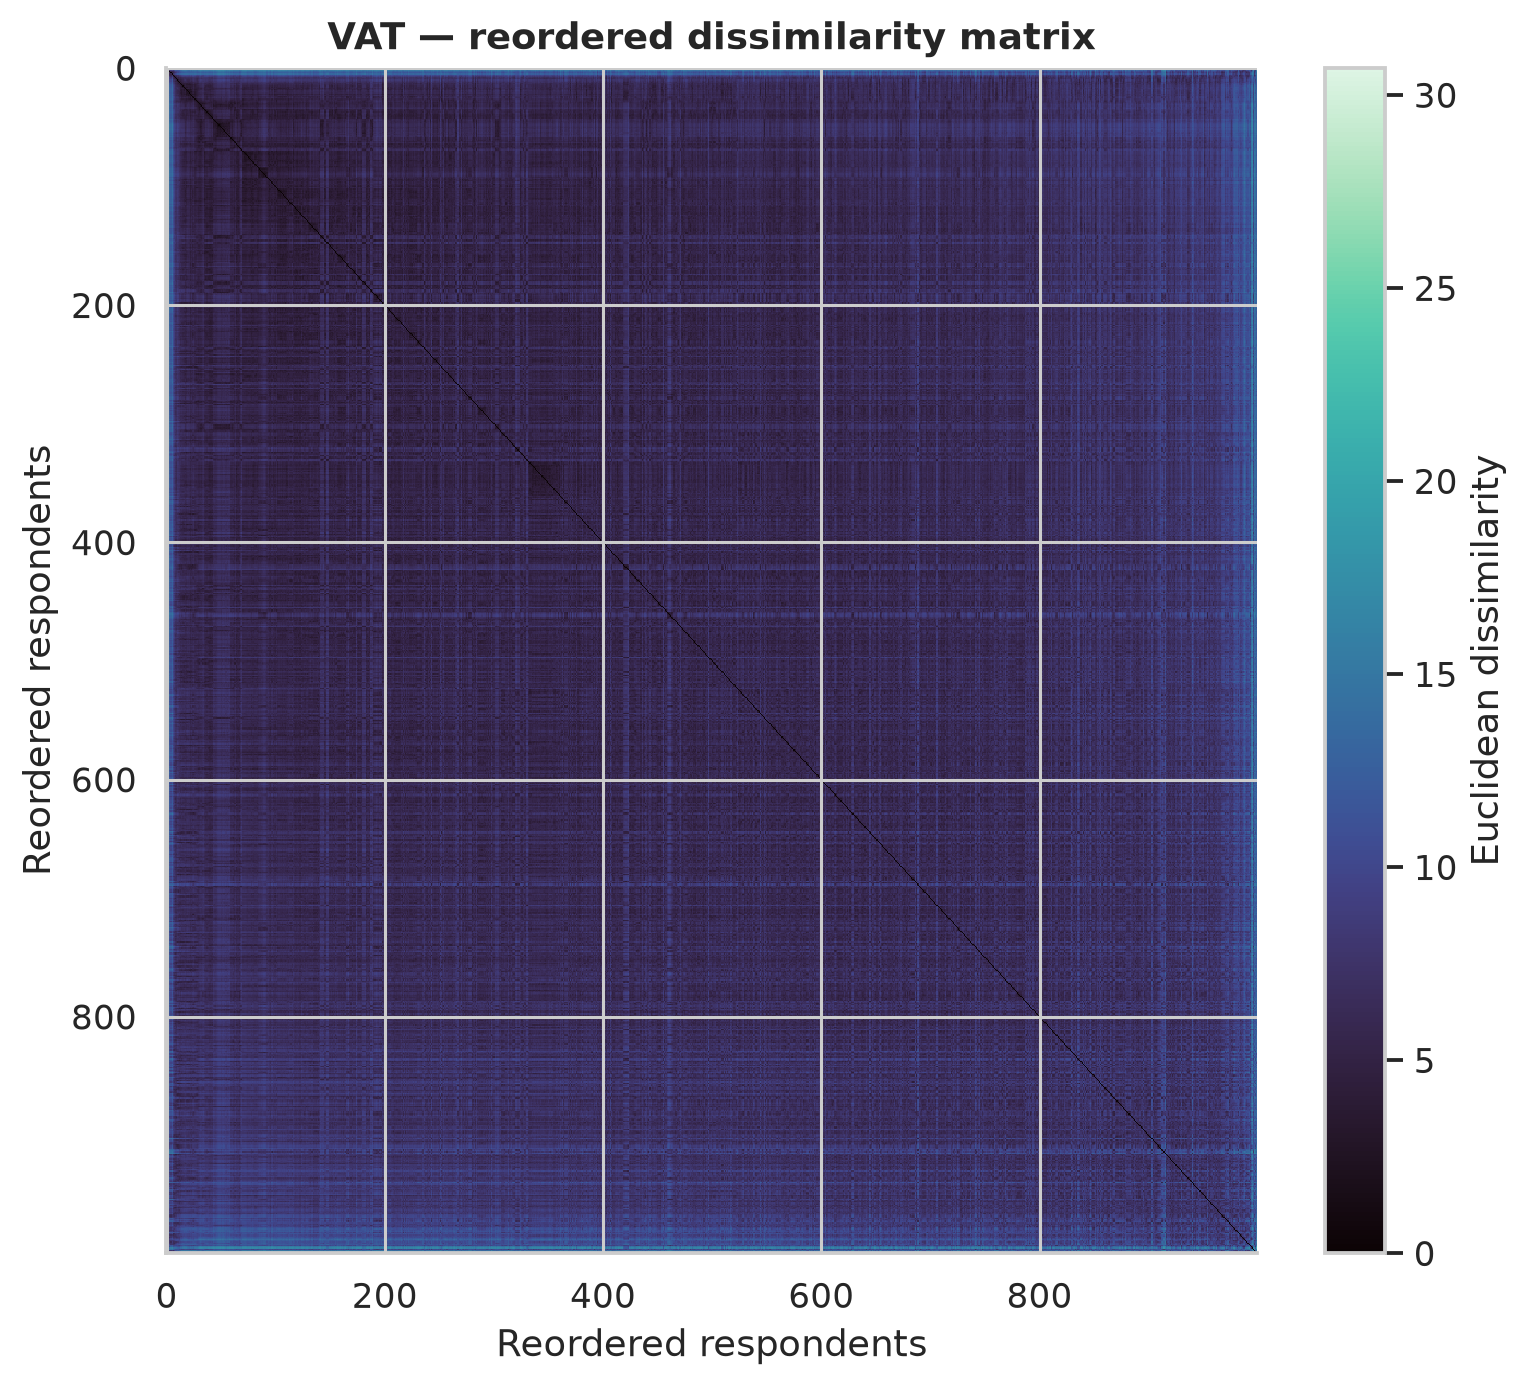

In [13]:
display(Image(filename=ROOT/'reports/figures/phase1_vat_heatmap.png', width=760))

میانگین Hopkins در تمام نمایش‌های گزارش‌شده بالاتر از آستانه عملی ۰٫۷ قرار دارد و نمایش PCA قوی‌ترین گرایش را نشان می‌دهد. VAT گرادیان و چند ناحیه پیوسته را بیش از بلوک‌های کاملا جدا نشان می‌دهد. جمع‌بندی محافظه‌کارانه این است که ساختار غیرتصادفی وجود دارد، اما هم‌پوشانی، شکل غیرکوژ و تغییر چگالی محتمل است؛ در نتیجه portfolio فاز دوم باید فراتر از K-Means باشد.

## ۵. نتیجه فاز اول

داده آمادگی ورود به مقایسه K-Means، خوشه‌بندی سلسله‌مراتبی، روش‌های چگالی، GMM و Spectral را دارد. تمام ماتریس‌ها، scalerها، reducerها، هش‌ها و جداول در artifactهای پروژه ثبت شده‌اند.